In [1]:
import fitsio
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path

In [2]:
data_dir = Path("./data/")

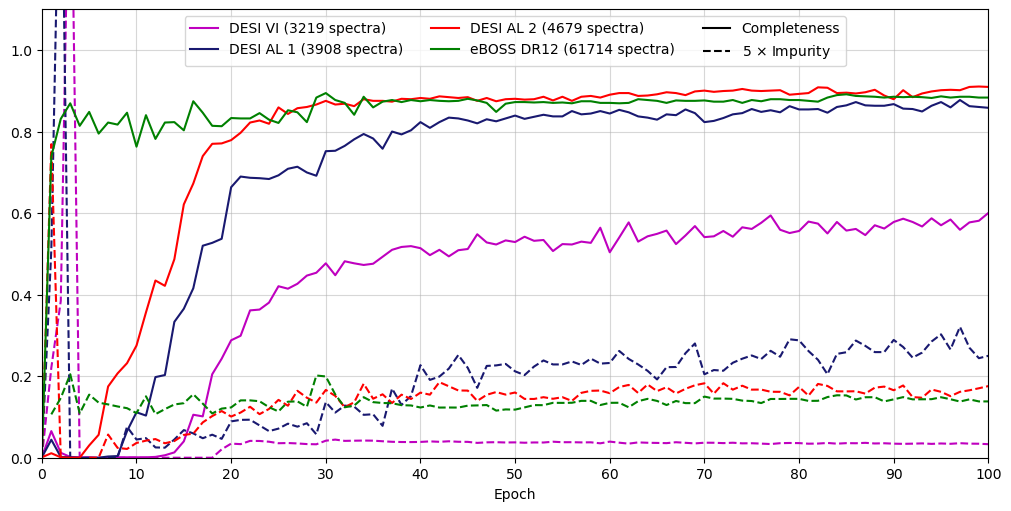

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5), layout="constrained")

# Original model
with fitsio.FITS(data_dir / "train_fuji+guadalupe_v0_log_6_layers_hist.fits") as h:
    d_pur = h[1].read(columns="purity")
    d_com = h[1].read(columns="completeness")

    ax.plot(5 * (1 - d_pur), "m", ls="dashed")
    ax.plot(d_com, ls="solid", color="m")
    
    ax.plot([], [], label="DESI VI (3219 spectra)", c="m")

with fitsio.FITS(data_dir / "train_fuji+guadalupe_v1_log_6_layers_hist.fits") as h:
    d_pur = h[1].read(columns="purity")
    d_com = h[1].read(columns="completeness")

    ax.plot(5 * (1 - d_pur), "#191970", ls="dashed")
    ax.plot(d_com, ls="solid", color="#191970")
    
    ax.plot([], [], label="DESI AL 1 (3908 spectra)", c="#191970")
    
with fitsio.FITS(data_dir / "train_fuji+guadalupe_v2_log_6_layers_hist.fits") as h:
    d_pur = h[1].read(columns="purity")
    d_com = h[1].read(columns="completeness")
    
    ax.plot(5 * (1 - d_pur), "r", ls="dashed")
    ax.plot(d_com, ls="solid", color="r")
    
    ax.plot([], [], label="DESI AL 2 (4679 spectra)", c="r")

with fitsio.FITS(data_dir / "train_dr12_log_6_layers_hist.fits") as h:
    d_pur = h[1].read(columns="purity")
    d_com = h[1].read(columns="completeness")

    ax.plot(5 * (1 - d_pur), "g", ls="dashed")
    ax.plot(d_com, ls="solid", color="g")
    
    ax.plot([], [], label="eBOSS DR12 (61714 spectra)", c="g")
    
ax.set(ylim=(0, 1.1), xlim=(0, 100))

ax.plot([], [], label="Completeness", c="k", ls="solid")
ax.plot([], [], label="5 $\\times$ Impurity", c="k", ls="dashed")


ax.grid(alpha=0.5)
ax.legend(ncol=3, loc="upper center")

plt.xlabel("Epoch")
plt.xticks(ticks=np.arange(0, 110, 10))
plt.savefig("plots/purcom_dr12vdesi.pdf", bbox_inches="tight")

data/bootstraps/train_fuji+guadalupe_v0_log_6_layers_btstrp_0_hist.fits
data/bootstraps/train_fuji+guadalupe_v0_log_6_layers_btstrp_1_hist.fits
data/bootstraps/train_fuji+guadalupe_v0_log_6_layers_btstrp_2_hist.fits
data/bootstraps/train_fuji+guadalupe_v0_log_6_layers_btstrp_3_hist.fits
data/bootstraps/train_fuji+guadalupe_v0_log_6_layers_btstrp_4_hist.fits
data/bootstraps/train_fuji+guadalupe_v0_log_6_layers_btstrp_5_hist.fits
data/bootstraps/train_fuji+guadalupe_v0_log_6_layers_btstrp_6_hist.fits
data/bootstraps/train_fuji+guadalupe_v0_log_6_layers_btstrp_7_hist.fits
data/bootstraps/train_fuji+guadalupe_v0_log_6_layers_btstrp_8_hist.fits
data/bootstraps/train_fuji+guadalupe_v0_log_6_layers_btstrp_9_hist.fits
data/bootstraps/train_fuji+guadalupe_v1_log_6_layers_btstrp_0_hist.fits
data/bootstraps/train_fuji+guadalupe_v1_log_6_layers_btstrp_1_hist.fits
data/bootstraps/train_fuji+guadalupe_v1_log_6_layers_btstrp_2_hist.fits
data/bootstraps/train_fuji+guadalupe_v1_log_6_layers_btstrp_3_hi

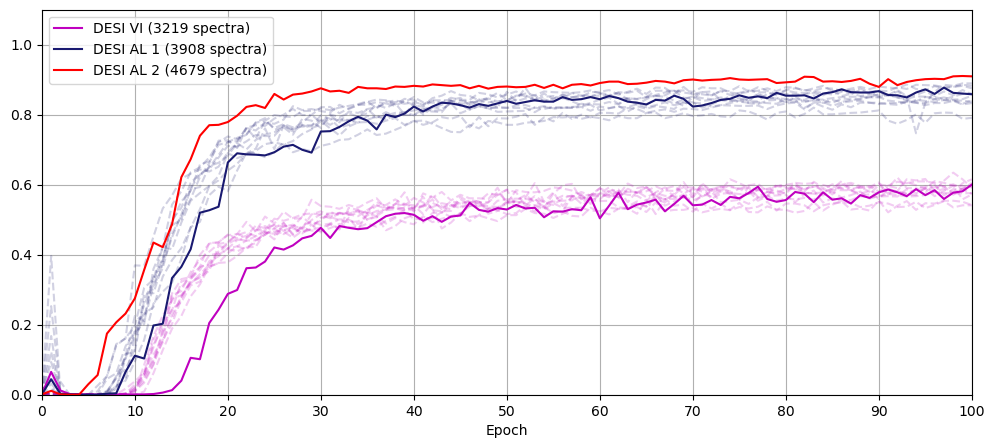

In [8]:
bootstrap_dir = data_dir / "bootstraps"
fig, ax = plt.subplots(figsize=(12, 5))

for f in sorted(bootstrap_dir.glob("*log*hist.fits")):
    print(f)
    with fitsio.FITS(f) as h:
        d_pur = h[1].read(columns="purity")
        d_com = h[1].read(columns="completeness")
        
    alpha = 0.2 if f.match("*btstrp*") else 1
    
    if f.match("*v0*"):
        c = "m"
    elif f.match("*v1*"):
        c = "#191970"
    else:
        c = "r"
        continue

    plt.plot(d_com, alpha=alpha, c=c, ls="dashed")
     

# Plotting the non-bootstrap loss
with fitsio.FITS(data_dir / "train_fuji+guadalupe_v0_log_6_layers_hist.fits") as h:
    d_pur = h[1].read(columns="purity")
    d_com = h[1].read(columns="completeness")

    plt.plot(d_com, color="m", label="DESI VI (3219 spectra)")
    
with fitsio.FITS(data_dir / "train_fuji+guadalupe_v1_log_6_layers_hist.fits") as h:
    d_pur = h[1].read(columns="purity")
    d_com = h[1].read(columns="completeness")

    plt.plot(d_com, color="#191970", label="DESI AL 1 (3908 spectra)")
    
with fitsio.FITS(data_dir / "train_fuji+guadalupe_v2_log_6_layers_hist.fits") as h:
    d_pur = h[1].read(columns="purity")
    d_com = h[1].read(columns="completeness")

    plt.plot(d_com, color="r", label="DESI AL 2 (4679 spectra)")
    

ax.set(ylim=(0, 1.1), xlim=(0, 100))
plt.xticks(ticks=np.arange(0, 110, 10))
plt.xlabel("Epoch")
plt.legend()
plt.grid()
plt.savefig("plots/boostrap_loss.pdf", bbox_inches="tight")